# Looking at scenarios.
- Default scenario.
- Scenario with no network effects.
- Scenario with no macro effects.

## 1. Preamble.
- Load packages.
- Include necessary scripts.

In [ ]:
using CSV
using DataFrames
using Random
using Parameters
using Distributions
using StatsBase
using Plots

In [1]:
include("run.jl")

run_seeds (generic function with 1 method)

## 2. Default scenario

- Define default scenarios. 
- No changes in micro nor macro effects.
- When modifying scenarios we use a type *Dict* because it allows to directly modify the factors we are interested in. See below in point 3 for an example.

In [19]:
const scenario_micro_default = Dict()
const scenario_macro_default = Dict()

Dict{Any, Any}()

- Create empty vectors to be filled with each of the simulation seeds.
- Run simulation for 10 seeds.

In [20]:
const vector_n_mig_default = []
const vector_mig_rate_default = []
const vector_cummig_rate_default = []
for seed in 1:10
	n_mig, n_nomig, mig_rate, cummig_rate, pop, cohort, d_mig, n_dead, rescaled = run_sim("data/lampABM.csv", "data/macro.csv", "data/stat_model_lampABM_mlogit.csv", 78, seed, "Spain", scenario_micro_default, scenario_macro_default);
	push!(vector_n_mig_default, n_mig[32:end]) # 1962 to 2008
	push!(vector_cummig_rate_default, cummig_rate[32:end])
	push!(vector_mig_rate_default, mig_rate[32:end])
end

Plot cumulative migration rates for the period of interest.

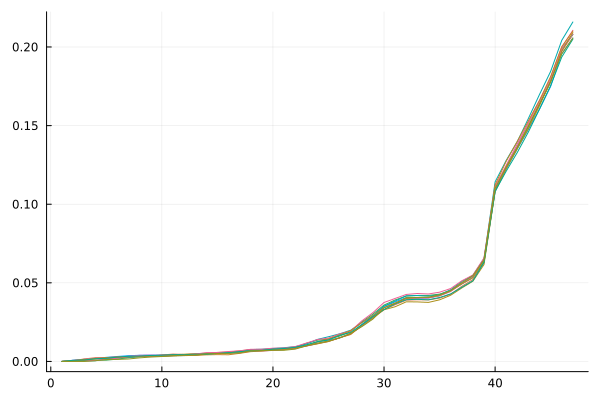

In [21]:
Plots.plot(vector_cummig_rate_default, labels = ["migrants"], legend = false)

## 3. Scenario with no network effects.

- Define scenario with no network effects *scenario_all_net_0*: positions 17 and 18 in vector with coefficients are family ties and community networks, respectively.
- Define empty vectors. We use the same name as before, given they are going to be overwritten.
- Run simulation, now with overriden scenario. **See fields within run_sim function**.

In [13]:
const scenario_all_net_0 = Dict(17 => 0, 18 => 0)

const vector_n_mig = []
const vector_cummig_rate = []
const vector_mig_rate = []

for seed in 1:10
	n_mig, n_nomig, mig_rate, cummig_rate, pop, cohort, d_mig, n_dead, rescaled = run_sim("data/lampABM.csv", "data/macro.csv", "data/stat_model_lampABM_mlogit.csv", 78, seed, "Spain", scenario_all_net_0, scenario_macro_default);
	push!(vector_n_mig, n_mig[32:end]) # 1962 to 2008
	push!(vector_cummig_rate, cummig_rate[32:end])
	push!(vector_mig_rate, mig_rate[32:end])
end

Removing network effects decreases cumulative migration rate to half.

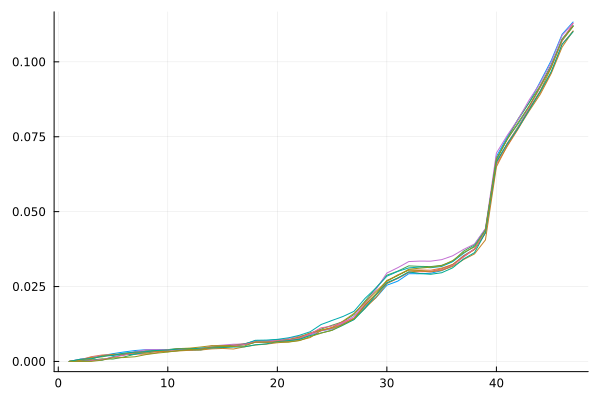

In [14]:
Plots.plot(vector_cummig_rate, labels = ["migrants"], legend = false)

## 4. Scenario with no employment growth effect.

In [15]:
const scenario_macro_employment_0 = Dict(6 => 0)

const vector_n_mig = []
const vector_cummig_rate = []
const vector_mig_rate = []

for seed in 1:10
	n_mig, n_nomig, mig_rate, cummig_rate, pop, cohort, d_mig, n_dead, rescaled = run_sim("data/lampABM.csv", "data/macro.csv", "data/stat_model_lampABM_mlogit.csv", 78, seed, "Spain", scenario_all_net_0, scenario_macro_employment_0);
	push!(vector_n_mig, n_mig[32:end]) # 1962 to 2008
	push!(vector_cummig_rate, cummig_rate[32:end])
	push!(vector_mig_rate, mig_rate[32:end])
end

Removing employment growth effect decreases migration rates even more than networks.

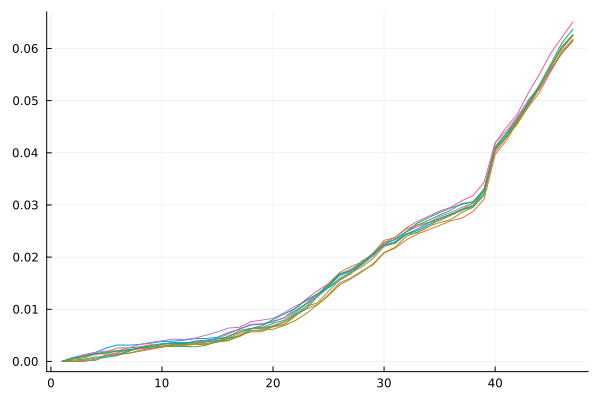

In [16]:
Plots.plot(vector_cummig_rate, labels = ["migrants"], legend = false)